# Lab 02: K-Nearest Neighbors - Distance Computation

In this lab you will build the distance-computation foundation of a K-Nearest
Neighbors (k-NN) classifier on the
[CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html).

You will implement squared Euclidean distance computation in three ways:

1. two explicit Python loops;
2. one Python loop;
3. a fully vectorized PyTorch implementation.

The goal is to practice tensor shapes, broadcasting, and vectorization while
measuring how implementation choices affect runtime. Label prediction and the
complete classifier continue in Lab 03.


# Setup Code


Run the following cell to verify that Python can import the local
`knn.py` file. It should print `Hello from knn.py!`.


In [1]:
import os
os.makedirs('dlcv2026', exist_ok=True)

knn_source = '"""\nImplements a K-Nearest Neighbor classifier in PyTorch.\n"""\nimport torch\nfrom typing import Dict, List\n\n\ndef hello():\n    """\n    This is a sample function that we will try to import and run to ensure that\n    our environment is correctly set up.\n    """\n    print("Hello from knn.py!")\n\n\ndef compute_distances_two_loops(x_train: torch.Tensor, x_test: torch.Tensor):\n    """\n    Computes the squared Euclidean distance between each element of training\n    set and each element of test set. Images should be flattened and treated\n    as vectors.\n    """\n    num_train = x_train.shape[0]\n    num_test = x_test.shape[0]\n    dists = x_train.new_zeros(num_train, num_test)\n\n    for i in range(num_train):\n        for j in range(num_test):\n            diff = x_train[i].reshape(-1) - x_test[j].reshape(-1)\n            dists[i, j] = (diff * diff).sum()\n\n    return dists\n\n\ndef compute_distances_one_loop(x_train: torch.Tensor, x_test: torch.Tensor):\n    """\n    Computes the squared Euclidean distance between each element of training\n    set and each element of test set using one Python loop.\n    """\n    num_train = x_train.shape[0]\n    num_test = x_test.shape[0]\n    dists = x_train.new_zeros(num_train, num_test)\n\n    x_test_flat = x_test.reshape(num_test, -1)\n\n    for i in range(num_train):\n        x_train_flat = x_train[i].reshape(-1)\n        diff = x_test_flat - x_train_flat\n        dists[i] = (diff * diff).sum(dim=1)\n\n    return dists\n\n\ndef compute_distances_no_loops(x_train: torch.Tensor, x_test: torch.Tensor):\n    """\n    Computes the squared Euclidean distance between each element of training\n    set and each element of test set without Python loops.\n    """\n    num_train = x_train.shape[0]\n    num_test = x_test.shape[0]\n\n    x_train_flat = x_train.reshape(num_train, -1)\n    x_test_flat = x_test.reshape(num_test, -1)\n\n    train_sq = (x_train_flat * x_train_flat).sum(dim=1, keepdim=True)\n    test_sq = (x_test_flat * x_test_flat).sum(dim=1).unsqueeze(0)\n    cross = x_train_flat.mm(x_test_flat.t())\n\n    dists = train_sq + test_sq - 2 * cross\n\n    return dists\n'
init_source = 'from . import data\nfrom .utils import reset_seed, tensor_to_image, visualize_dataset\n'
data_source = 'import os\nimport random\n\nimport matplotlib.pyplot as plt\nimport torch\nimport torchvision\nfrom torchvision.datasets import CIFAR10\n\nimport dlcv2026\n\n\ndef _extract_tensors(dset, num=None, x_dtype=torch.float32):\n    """\n    Extract the data and labels from a CIFAR10 dataset object and convert them to\n    tensors.\n\n    Input:\n    - dset: A torchvision.datasets.CIFAR10 object\n    - num: Optional. If provided, the number of samples to keep.\n    - x_dtype: Optional. data type of the input image\n\n    Returns:\n    - x: `x_dtype` tensor of shape (N, 3, 32, 32)\n    - y: int64 tensor of shape (N,)\n    """\n    x = torch.tensor(dset.data, dtype=x_dtype).permute(0, 3, 1, 2).div_(255)\n    y = torch.tensor(dset.targets, dtype=torch.int64)\n    if num is not None:\n        if num <= 0 or num > x.shape[0]:\n            raise ValueError(\n                "Invalid value num=%d; must be in the range [0, %d]" % (num, x.shape[0])\n            )\n        x = x[:num].clone()\n        y = y[:num].clone()\n    return x, y\n\n\ndef cifar10(num_train=None, num_test=None, x_dtype=torch.float32):\n    """\n    Return the CIFAR10 dataset, automatically downloading it if necessary.\n    This function can also subsample the dataset.\n\n    Inputs:\n    - num_train: [Optional] How many samples to keep from the training set.\n      If not provided, then keep the entire training set.\n    - num_test: [Optional] How many samples to keep from the test set.\n      If not provided, then keep the entire test set.\n    - x_dtype: [Optional] Data type of the input image\n\n    Returns:\n    - x_train: `x_dtype` tensor of shape (num_train, 3, 32, 32)\n    - y_train: int64 tensor of shape (num_train,)\n    - x_test: `x_dtype` tensor of shape (num_test, 3, 32, 32)\n    - y_test: int64 tensor of shape (num_test,)\n    """\n    download = not os.path.isdir("cifar-10-batches-py")\n    dset_train = CIFAR10(root=".", download=download, train=True)\n    dset_test = CIFAR10(root=".", train=False)\n    x_train, y_train = _extract_tensors(dset_train, num_train, x_dtype)\n    x_test, y_test = _extract_tensors(dset_test, num_test, x_dtype)\n\n    return x_train, y_train, x_test, y_test\n\n\ndef preprocess_cifar10(\n    cuda=True,\n    show_examples=True,\n    bias_trick=False,\n    flatten=True,\n    validation_ratio=0.2,\n    dtype=torch.float32,\n):\n    """\n    Returns a preprocessed version of the CIFAR10 dataset, automatically\n    downloading if necessary. We perform the following steps:\n\n    (0) [Optional] Visualize some images from the dataset\n    (1) Normalize the data by subtracting the mean\n    (2) Reshape each image of shape (3, 32, 32) into a vector of shape (3072,)\n    (3) [Optional] Bias trick: add an extra dimension of ones to the data\n    (4) Carve out a validation set from the training set\n\n    Inputs:\n    - cuda: If true, move the entire dataset to the GPU\n    - validation_ratio: Float in the range (0, 1) giving the fraction of the train\n      set to reserve for validation\n    - bias_trick: Boolean telling whether or not to apply the bias trick\n    - show_examples: Boolean telling whether or not to visualize data samples\n    - dtype: Optional, data type of the input image X\n\n    Returns a dictionary with the following keys:\n    - \'X_train\': `dtype` tensor of shape (N_train, D) giving training images\n    - \'X_val\': `dtype` tensor of shape (N_val, D) giving val images\n    - \'X_test\': `dtype` tensor of shape (N_test, D) giving test images\n    - \'y_train\': int64 tensor of shape (N_train,) giving training labels\n    - \'y_val\': int64 tensor of shape (N_val,) giving val labels\n    - \'y_test\': int64 tensor of shape (N_test,) giving test labels\n\n    N_train, N_val, and N_test are the number of examples in the train, val, and\n    test sets respectively. The precise values of N_train and N_val are determined\n    by the input parameter validation_ratio. D is the dimension of the image data;\n    if bias_trick is False, then D = 32 * 32 * 3 = 3072;\n    if bias_trick is True then D = 1 + 32 * 32 * 3 = 3073.\n    """\n    X_train, y_train, X_test, y_test = cifar10(x_dtype=dtype)\n\n    # Move data to the GPU\n    if cuda:\n        X_train = X_train.cuda()\n        y_train = y_train.cuda()\n        X_test = X_test.cuda()\n        y_test = y_test.cuda()\n\n    # 0. Visualize some examples from the dataset.\n    if show_examples:\n        classes = [\n            "plane",\n            "car",\n            "bird",\n            "cat",\n            "deer",\n            "dog",\n            "frog",\n            "horse",\n            "ship",\n            "truck",\n        ]\n        samples_per_class = 12\n        samples = []\n        dlcv2026.reset_seed(0)\n        for y, cls in enumerate(classes):\n            plt.text(-4, 34 * y + 18, cls, ha="right")\n            (idxs,) = (y_train == y).nonzero(as_tuple=True)\n            for i in range(samples_per_class):\n                idx = idxs[random.randrange(idxs.shape[0])].item()\n                samples.append(X_train[idx])\n        img = torchvision.utils.make_grid(samples, nrow=samples_per_class)\n        plt.imshow(dlcv2026.tensor_to_image(img))\n        plt.axis("off")\n        plt.show()\n\n    # 1. Normalize the data: subtract the mean RGB (zero mean)\n    mean_image = X_train.mean(dim=(0, 2, 3), keepdim=True)\n    X_train -= mean_image\n    X_test -= mean_image\n\n    # 2. Reshape the image data into rows\n    if flatten:\n        X_train = X_train.reshape(X_train.shape[0], -1)\n        X_test = X_test.reshape(X_test.shape[0], -1)\n\n    # 3. Add bias dimension and transform into columns\n    if bias_trick:\n        ones_train = torch.ones(X_train.shape[0], 1, device=X_train.device)\n        X_train = torch.cat([X_train, ones_train], dim=1)\n        ones_test = torch.ones(X_test.shape[0], 1, device=X_test.device)\n        X_test = torch.cat([X_test, ones_test], dim=1)\n\n    # 4. take the validation set from the training set\n    # Note: It should not be taken from the test set\n    # For random permumation, you can use torch.randperm or torch.randint\n    # But, for this homework, we use slicing instead.\n    num_training = int(X_train.shape[0] * (1.0 - validation_ratio))\n    num_validation = X_train.shape[0] - num_training\n\n    # return the dataset\n    data_dict = {}\n    data_dict["X_val"] = X_train[num_training : num_training + num_validation]\n    data_dict["y_val"] = y_train[num_training : num_training + num_validation]\n    data_dict["X_train"] = X_train[0:num_training]\n    data_dict["y_train"] = y_train[0:num_training]\n\n    data_dict["X_test"] = X_test\n    data_dict["y_test"] = y_test\n    return data_dict\n'
utils_source = '"""\nGeneral utilities to help with implementation\n"""\nimport random\n\nimport matplotlib.pyplot as plt\nimport torch\n\n\ndef reset_seed(number):\n    """\n    Reset random seed to the specific number\n\n    Inputs:\n    - number: A seed number to use\n    """\n    random.seed(number)\n    torch.manual_seed(number)\n    return\n\n\ndef tensor_to_image(tensor):\n    """\n    Convert a torch tensor into a numpy ndarray for visualization.\n\n    Inputs:\n    - tensor: A torch tensor of shape (3, H, W) with elements in the range [0, 1]\n\n    Returns:\n    - ndarr: A uint8 numpy array of shape (H, W, 3)\n    """\n    tensor = tensor.mul(255).add_(0.5).clamp_(0, 255).permute(1, 2, 0)\n    ndarr = tensor.to("cpu", torch.uint8).numpy()\n    return ndarr\n\n\ndef visualize_dataset(X_data, y_data, samples_per_class, class_list):\n    """\n    Make a grid-shape image to plot\n\n    Inputs:\n    - X_data: set of [batch, 3, width, height] data\n    - y_data: paired label of X_data in [batch] shape\n    - samples_per_class: number of samples want to present\n    - class_list: list of class names (e.g.) [\'plane\', \'car\', \'bird\', \'cat\',\n      \'deer\', \'dog\', \'frog\', \'horse\', \'ship\', \'truck\']\n\n    Outputs:\n    - An grid-image that visualize samples_per_class number of samples per class\n    """\n\n    # Protected lazy import.\n    from torchvision.utils import make_grid\n\n    img_half_width = X_data.shape[2] // 2\n    samples = []\n    for y, cls in enumerate(class_list):\n        plt.text(\n            -4, (img_half_width * 2 + 2) * y + (img_half_width + 2), cls, ha="right"\n        )\n        idxs = (y_data == y).nonzero().view(-1)\n        for i in range(samples_per_class):\n            idx = idxs[random.randrange(idxs.shape[0])].item()\n            samples.append(X_data[idx])\n\n    img = make_grid(samples, nrow=samples_per_class)\n    return tensor_to_image(img)\n'

with open('knn.py', 'w', encoding='utf-8') as f:
    f.write(knn_source)
with open('dlcv2026/__init__.py', 'w', encoding='utf-8') as f:
    f.write(init_source)
with open('dlcv2026/data.py', 'w', encoding='utf-8') as f:
    f.write(data_source)
with open('dlcv2026/utils.py', 'w', encoding='utf-8') as f:
    f.write(utils_source)


In [2]:
from knn import hello

hello()


Hello from knn.py!


# Data preprocessing / Visualization

## Setup code
Run some setup code for this notebook: Import some useful packages and increase the default figure size.

In [3]:
import dlcv2026
import torch
import torchvision
import matplotlib.pyplot as plt
import statistics

plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['font.size'] = 16

## Load the CIFAR-10 dataset
The utility function `dlcv2026.data.cifar10()` returns the entire CIFAR-10 dataset as a set of four **Torch tensors**:

- `x_train` contains all training images (real numbers in the range $[0, 1]$)
- `y_train` contains all training labels (integers in the range $[0, 9]$)
- `x_test` contains all test images
- `y_test` contains all test labels

This function automatically downloads the CIFAR-10 dataset the first time you run it.

In [4]:
x_train, y_train, x_test, y_test = dlcv2026.data.cifar10()

print('Training set:', )
print('  data shape:', x_train.shape)
print('  labels shape: ', y_train.shape)
print('Test set:')
print('  data shape: ', x_test.shape)
print('  labels shape', y_test.shape)

100.0%
c:\Users\YASSER\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training set:
  data shape: torch.Size([50000, 3, 32, 32])
  labels shape:  torch.Size([50000])
Test set:
  data shape:  torch.Size([10000, 3, 32, 32])
  labels shape torch.Size([10000])


## Visualize the dataset
To give you a sense of the nature of the images in CIFAR-10, this cell visualizes some random examples from the training set.

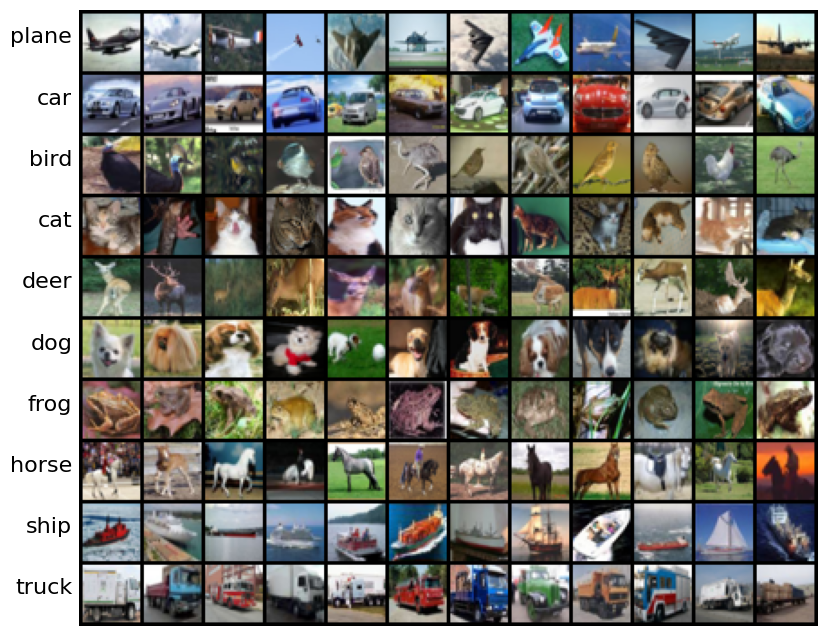

In [5]:
import random
from torchvision.utils import make_grid

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
samples_per_class = 12
samples = []
for y, cls in enumerate(classes):
    plt.text(-4, 34 * y + 18, cls, ha='right')
    idxs, = (y_train == y).nonzero(as_tuple=True)
    for i in range(samples_per_class):
        idx = idxs[random.randrange(idxs.shape[0])].item()
        samples.append(x_train[idx])
img = torchvision.utils.make_grid(samples, nrow=samples_per_class)
plt.imshow(dlcv2026.tensor_to_image(img))
plt.axis('off')
plt.show()

## Subsample the dataset
When implementing machine learning algorithms, it's usually a good idea to use a small sample of the full dataset. This way your code will run much faster, allowing for more interactive and efficient development. Once you are satisfied that you have correctly implemented the algorithm, you can then rerun with the entire dataset.

The function `dlcv2026.data.cifar10()` can automatically subsample the CIFAR10 dataset for us. To see how to use it, we can check the documentation using the built-in `help` command:

In [6]:
help(dlcv2026.data.cifar10)

Help on function cifar10 in module dlcv2026.data:

cifar10(num_train=None, num_test=None, x_dtype=torch.float32)
    Return the CIFAR10 dataset, automatically downloading it if necessary.
    This function can also subsample the dataset.

    Inputs:
    - num_train: [Optional] How many samples to keep from the training set.
      If not provided, then keep the entire training set.
    - num_test: [Optional] How many samples to keep from the test set.
      If not provided, then keep the entire test set.
    - x_dtype: [Optional] Data type of the input image

    Returns:
    - x_train: `x_dtype` tensor of shape (num_train, 3, 32, 32)
    - y_train: int64 tensor of shape (num_train,)
    - x_test: `x_dtype` tensor of shape (num_test, 3, 32, 32)
    - y_test: int64 tensor of shape (num_test,)



We will subsample the data to use only 500 training examples and 250 test examples:

In [7]:
num_train = 500
num_test = 250

x_train, y_train, x_test, y_test = dlcv2026.data.cifar10(num_train, num_test)

print('Training set:', )
print('  data shape:', x_train.shape)
print('  labels shape: ', y_train.shape)
print('Test set:')
print('  data shape: ', x_test.shape)
print('  labels shape', y_test.shape)

Training set:
  data shape: torch.Size([500, 3, 32, 32])
  labels shape:  torch.Size([500])
Test set:
  data shape:  torch.Size([250, 3, 32, 32])
  labels shape torch.Size([250])


# K-Nearest Neighbors (k-NN)

## Compute distances: Naive implementation
Now that we have examined and prepared our data, it is time to implement the kNN classifier. We can break the process down into two steps:

1. Compute the (squared Euclidean) distances between all training examples and all test examples
2. Given these distances, for each test example find its k nearest neighbors and have them vote for the label to output

Lets begin with computing the distance matrix between all training and test examples. First we will implement a naive version of the distance computation, using explicit loops over the training and test sets. In the file `knn.py`, implement the function `compute_distances_two_loops`.

**NOTE: When implementing distance functions for this Practice, you may not use functions `torch.norm` or `torch.dist` (or their instance method variants `x.norm` / `x.dist`); you may not use any functions from `torch.nn` or `torch.nn.functional`.**

In [8]:
from knn import compute_distances_two_loops

torch.manual_seed(0)
num_train = 500
num_test = 250
x_train, y_train, x_test, y_test = dlcv2026.data.cifar10(num_train, num_test)

dists = compute_distances_two_loops(x_train, x_test)
print('dists has shape: ', dists.shape)

dists has shape:  torch.Size([500, 250])


### Check the two-loop implementation

Before comparing implementations, verify the two-loop result against a small
distance matrix whose values are known. This test checks both the output shape
and the numerical values.


In [9]:
x_train_small = torch.tensor([[0.0, 0.0], [3.0, 4.0]], dtype=torch.float64)
x_test_small = torch.tensor([[0.0, 4.0], [3.0, 0.0]], dtype=torch.float64)
expected = torch.tensor([[16.0, 9.0], [9.0, 16.0]], dtype=torch.float64)

actual = compute_distances_two_loops(x_train_small, x_test_small)
assert actual.shape == (2, 2), f"Expected shape (2, 2), got {tuple(actual.shape)}"
assert torch.allclose(actual, expected), f"Expected {expected}, got {actual}"
print("Two-loop distance test passed.")


Two-loop distance test passed.


## Compute distances: Vectorization
Our implementation of the distance computation above is fairly inefficient since it uses nested Python loops over the training and test sets.

When implementing algorithms in PyTorch, it's best to avoid loops in Python if possible. Instead it is preferable to implement your computation so that all loops happen inside PyTorch functions. This will usually be much faster than writing your own loops in Python, since PyTorch functions can be internally optimized to iterate efficiently, possibly using multiple threads. This is especially important when using a GPU to accelerate your code.

The process of eliminating explict loops from your code is called **vectorization**. Sometimes it is straighforward to vectorize code originally written with loops; other times vectorizing requires thinking about the problem in a new way. We will use vectorization to improve the speed of our distance computation function.

As a first step toward vectorizing our distance computation, you will implement a version that uses only a single Python loop over the training data. In the file `knn.py`, complete the implementation of the function `compute_distances_one_loop`.

We can check the correctness of our one-loop implementation by comparing it with our two-loop implementation on some randomly generated data.


In [10]:
from knn import compute_distances_one_loop
from knn import compute_distances_two_loops

torch.manual_seed(0)
x_train_rand = torch.randn(100, 3, 16, 16, dtype=torch.float64)
x_test_rand = torch.randn(100, 3, 16, 16, dtype=torch.float64)

dists_one = compute_distances_one_loop(x_train_rand, x_test_rand)
dists_two = compute_distances_two_loops(x_train_rand, x_test_rand)
difference = (dists_one - dists_two).pow(2).sum().sqrt().item()
print('Difference: ', difference)
if difference < 1e-4:
    print('Good! The distance matrices match')
else:
    print('Uh-oh! The distance matrices are different')

Difference:  0.0
Good! The distance matrices match


You will now implement a fully vectorized version of the distance computation function
that does not use any Python loops. In the file `knn.py`, implement the function `compute_distances_no_loops`.

As before, we can check the correctness of our implementation by comparing the fully vectorized version against the original naive version:

In [11]:
from knn import compute_distances_two_loops
from knn import compute_distances_no_loops

torch.manual_seed(0)
x_train_rand = torch.randn(100, 3, 16, 16, dtype=torch.float64)
x_test_rand = torch.randn(100, 3, 16, 16, dtype=torch.float64)

dists_two = compute_distances_two_loops(x_train_rand, x_test_rand)
dists_none = compute_distances_no_loops(x_train_rand, x_test_rand)
difference = (dists_two - dists_none).pow(2).sum().sqrt().item()
print('Difference: ', difference)
if difference < 1e-10:
  print('Good! The distance matrices match')
else:
  print('Uh-oh! The distance matrices are different')

Difference:  1.8975828319258947e-11
Good! The distance matrices match


We can now compare the speed of our three implementations. If you've implemented everything properly, the one-loop implementation should take less than 4 seconds to run, and the fully vectorized implementation should take less than 0.1 seconds to run.

In [12]:
import time
from knn import compute_distances_two_loops
from knn import compute_distances_one_loop
from knn import compute_distances_no_loops

def timeit(f, *args):
    tic = time.time()
    f(*args) 
    toc = time.time()
    return toc - tic

torch.manual_seed(0)
x_train_rand = torch.randn(500, 3, 32, 32)
x_test_rand = torch.randn(500, 3, 32, 32)

two_loop_time = timeit(compute_distances_two_loops, x_train_rand, x_test_rand)
print('Two loop version took %.2f seconds' % two_loop_time)

one_loop_time = timeit(compute_distances_one_loop, x_train_rand, x_test_rand)
speedup = two_loop_time / one_loop_time
print('One loop version took %.2f seconds (%.1fX speedup)'
      % (one_loop_time, speedup))

no_loop_time = timeit(compute_distances_no_loops, x_train_rand, x_test_rand)
speedup = two_loop_time / no_loop_time
print('No loop version took %.2f seconds (%.1fX speedup)'
      % (no_loop_time, speedup))

Two loop version took 9.72 seconds
One loop version took 1.07 seconds (9.0X speedup)
No loop version took 0.02 seconds (497.8X speedup)
